In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[1,2], [2,2], [2,3], [8,7], [8,8], [25,80]])

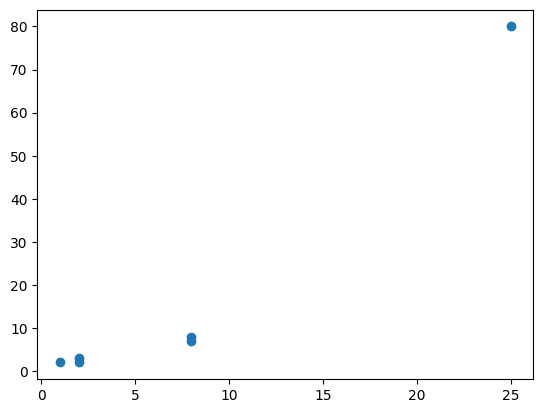

In [2]:
plt.scatter(X[:,0], X[:,1])
plt.show()

In [3]:
db = DBSCAN(eps=3, min_samples=2)
db.fit(X)
db.labels_

array([ 0,  0,  0,  1,  1, -1])

In [5]:
db = DBSCAN(eps=3, min_samples=3)
db.fit(X)
db.labels_

array([ 0,  0,  0, -1, -1, -1])

In [6]:
db = DBSCAN(eps=10, min_samples=2)
db.fit(X)
db.labels_

array([ 0,  0,  0,  0,  0, -1])

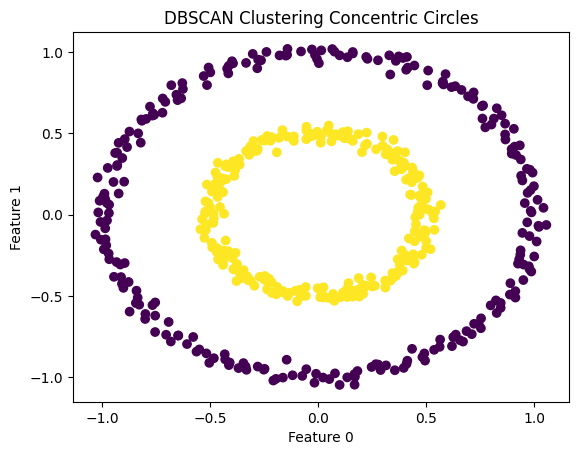

In [17]:
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.03, random_state=4)

dbscans = DBSCAN(eps=0.1, min_samples=5)
clusters = dbscans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=clusters, cmap='viridis', marker='o')
plt.title('DBSCAN Clustering Concentric Circles')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.show()

Generate Clustering Data

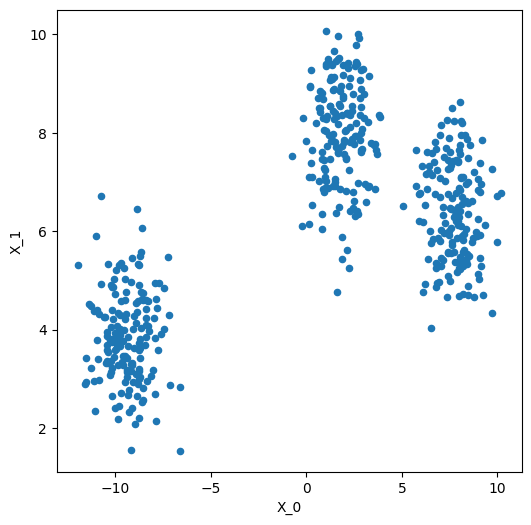

In [32]:
from sklearn.datasets import make_blobs
from pandas import DataFrame

X, _ = make_blobs(n_samples=500, centers=3, n_features=2, random_state=20)

df = DataFrame(dict(x=X[:,0], y=X[:,1]))
fig, ax = plt.subplots(figsize=(6,6))
df.plot(ax=ax, kind='scatter', x='x', y='y')
plt.xlabel('X_0')
plt.ylabel('X_1')
plt.show()

In [33]:
clustering = DBSCAN(eps=1, min_samples=5).fit(X)
cluster = clustering.labels_
len(set(cluster))

4

In [34]:
clustering.labels_

array([ 0,  1,  0,  0,  1,  1,  2,  2,  0,  0,  0,  1,  2,  2,  2,  0,  1,
        0,  2,  2,  0,  0,  1,  2,  1,  1,  0,  1,  0,  2,  2,  2,  1,  2,
        0,  1,  0,  2,  1,  1,  2,  1,  2,  2,  2,  2,  0,  0,  0,  2,  2,
        2,  1,  1,  1,  0,  2,  1,  2,  2,  0,  2,  2,  1,  2,  0,  0,  2,
        0,  2,  2,  1,  2,  2,  1,  0,  0,  0,  2,  0,  1,  1,  0,  0,  0,
        2,  2,  2,  0,  2,  0,  2,  2,  0,  0,  2,  1,  0,  2,  0,  1,  2,
        1,  0,  2,  2,  2,  1,  1,  0,  0, -1,  0,  0,  0,  1,  1,  0,  1,
        2,  1,  2,  2,  0,  0,  2,  1,  2,  1,  2,  0,  2,  1,  0,  1,  1,
        2,  0,  2,  1,  1,  2,  2,  1,  1,  1,  2,  0,  2,  1,  0,  0,  0,
        0,  0,  1,  2,  0,  1,  0,  2,  0,  0,  2,  0,  0,  0,  0,  0,  0,
        2,  0,  1,  1,  2,  2,  2,  2,  0,  1,  1,  1,  1,  2,  0,  2,  1,
        2,  1,  2,  1,  1,  0,  1,  1,  1,  2,  2,  1,  1,  0,  2,  2,  1,
        0,  2,  2,  1,  2,  1,  0,  0,  1,  1,  0,  2,  1,  1,  0,  2,  0,
        2,  0,  2,  0,  2

In [35]:
np.sum(clustering.labels_==-1)

np.int64(2)

In [36]:
def show_cluster(X, cluster):
  df=DataFrame(dict(x=X[:,0], y=X[:,1], label=cluster))
  colors={-1:'red', 0:'blue', 1:'green', 2:'orange'}
  fig, ax=plt.subplots(figsize=(6,6))
  grouped=df.groupby('label')
  for key,group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
  plt.xlabel('X_1')
  plt.ylabel('X_2')
  plt.show()

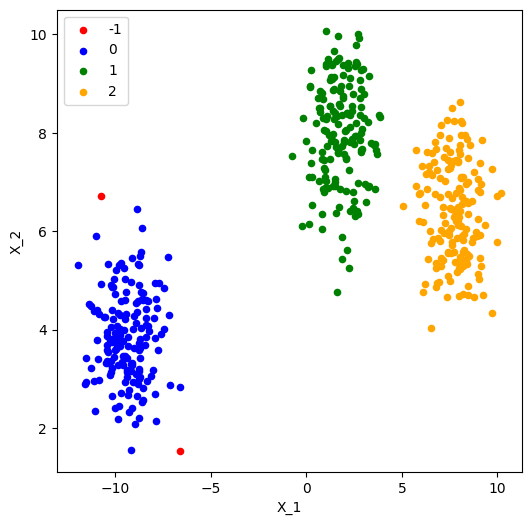

In [37]:
show_cluster(X, cluster)

In [39]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('/content/Mall_Customers_sample.csv')

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db1 = DBSCAN(eps=1.2, min_samples=4)
clusters_before = db1.fit_predict(X_scaled)

In [40]:
np.sum(clusters_before==-1)

np.int64(0)

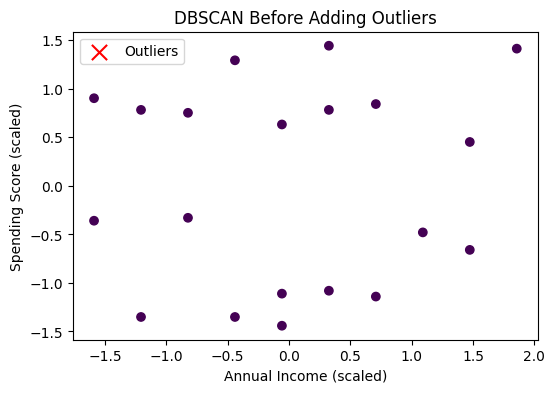

In [43]:
# plot BEFORE
plt.figure(figsize=(6,4))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters_before,
            cmap='viridis')

plt.scatter(X_scaled[clusters_before==-1,0],
            X_scaled[clusters_before==-1,1],
            color='red',
            marker='x',
            s=120,
            label='Outliers')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("DBSCAN Before Adding Outliers")
plt.legend()
plt.show()

In [56]:
new_points = np.array([
    [200,3],
    [5,95],
    [210,2]
])

X_new = np.vstack((X.values, new_points))
X_new_scaled = scaler.fit_transform(X_new)
db2 = DBSCAN(eps=1.2, min_samples=4)
clusters_after = db2.fit_predict(X_new_scaled)

In [57]:
np.sum(clusters_after==-1)

np.int64(2)

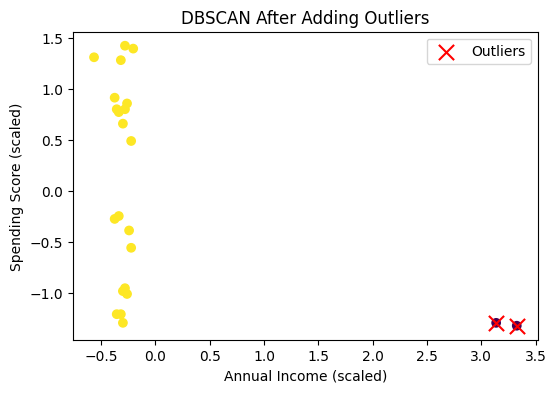

In [58]:
#plot AFTER
plt.figure(figsize=(6,4))

plt.scatter(X_new_scaled[:,0], X_new_scaled[:,1],
            c=clusters_after,
            cmap='viridis')

plt.scatter(X_new_scaled[clusters_after==-1,0],
            X_new_scaled[clusters_after==-1,1],
            color='red',
            marker='x',
            s=120,
            label='Outliers')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("DBSCAN After Adding Outliers")
plt.legend()
plt.show()

In [59]:
np.sum(clusters_after!=-1)

np.int64(21)

Conclusion: As we have added three new points to the mall customer dataset the scaling of axis changes as we have scaled the dataset, only two points get detected as outliers.